# `detector2d` — 2D detector geometry & trajectory intersection

`detector2d` is the pure-math foundation of the whole `aihep` suite: no
pandas, no I/O, just geometry. In 2D, a 3D plane detector becomes a straight
line segment and a 3D barrel cylinder becomes a circle. A charged particle in
a constant field `Bz` moves on a circular arc; a straight line is just the
`radius -> infinity` limit of the same arc.

This notebook walks through the package's building blocks in the same order
as its own README: trajectories & intersections, barrel layers, calorimeter
rings, muon stations, piecewise-field propagation, and declarative
(YAML-driven) detector layouts.


In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import yaml

from detector2d import (
    CircleLayer, LineLayer, Trajectory,
    intersect, first_intersection, signed_radius,
)
from detector2d.barrel import build_barrel_circle, build_barrel_modules
from detector2d.calorimeter import build_calo_stack
from detector2d.polygon import build_muon_system
from detector2d.field import FieldRegion, FieldRegions
from detector2d.propagate import propagate
from detector2d.config import build_layers_from_raw


## Trajectories and intersections

A `Trajectory(x0, y0, phi0, radius=None)` starts at `(x0, y0)` heading at
angle `phi0`. `radius=None` is a straight line; a finite signed `radius` is a
circular arc — **positive curls left (CCW)** as the particle moves forward,
negative curls right. This is exactly `1/kappa` for the usual signed
curvature `kappa = q*Bz/pt`.

`signed_radius(pt, charge, bz, k)` is the *only* place physical units (GeV,
Tesla) enter the package — everything else works in whatever length unit you
pick for your detector layout.


In [2]:
layer = LineLayer(layer_id=0, p1=(10.0, -50.0), p2=(10.0, 50.0))

straight = Trajectory(x0=0.0, y0=0.0, phi0=0.0)
hit = first_intersection(straight, layer)
print("straight track hit:", hit)

# pt=5 GeV, charge=+1, bz=1.5 T -> a real, physical signed radius
radius = signed_radius(pt=5.0, charge=+1, bz=1.5)
bent = Trajectory(x0=0.0, y0=0.0, phi0=0.0, radius=radius)
hit_bent = first_intersection(bent, layer)
print(f"bent track radius: {radius:.2f}, hit: {hit_bent}")


straight track hit: Hit(s=10.0, x=10.0, y=0.0, local_coord=50.0)
bent track radius: 11.12, hit: Hit(s=12.434900719310647, x=10.0, y=6.25832141362087, local_coord=56.25832141362087)


Text(0.5, 1.0, 'Straight vs. curved trajectory through a line layer')

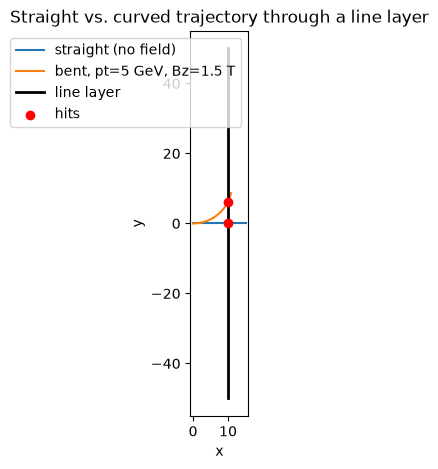

In [3]:
fig, ax = plt.subplots(figsize=(5, 5))
s_vals = np.linspace(0, 15, 200)
for traj, label in [(straight, "straight (no field)"), (bent, "bent, pt=5 GeV, Bz=1.5 T")]:
    xs, ys = zip(*(traj.position(s) for s in s_vals))
    ax.plot(xs, ys, label=label)
ax.plot([layer.p1[0], layer.p2[0]], [layer.p1[1], layer.p2[1]], "k-", lw=2, label="line layer")
ax.scatter([hit.x, hit_bent.x], [hit.y, hit_bent.y], color="red", zorder=5, label="hits")
ax.set_aspect("equal")
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.legend()
ax.set_title("Straight vs. curved trajectory through a line layer")


Note the smaller-radius case above: with `pt=2 GeV` the circle's diameter
(~8.9) is *smaller* than the layer's x-distance (10), so it never reaches the
layer at all and `first_intersection` returns `None` — geometry, not a bug.
`intersect`/`first_intersection` only look forward (`s > 0`); crossings
behind the trajectory's start are filtered out.


## Building a barrel layer

A real cylindrical tracker layer isn't one continuous circle — it's a ring of
flat, tilted, overlapping sensor modules (so a track crossing an overlap
gets two redundant hits, used for alignment in real detectors).
`build_barrel_circle` gives the simplified single-circle version;
`build_barrel_modules` gives the detailed tiled-module version. The module
*count* is derived from `overlap_fraction`, not configured directly.


27 modules cover the ring at radius 29.0


Text(0.5, 1.0, 'Barrel layer: 27 tilted, overlapping modules')

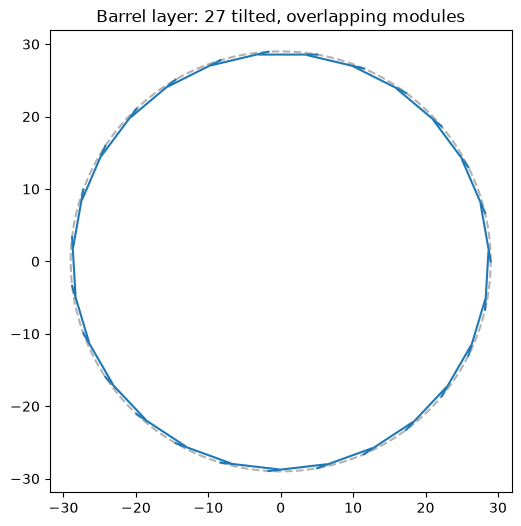

In [4]:
circle_layer = build_barrel_circle(layer_id=0, radius=29.0, pitch=0.1)
modules = build_barrel_modules(
    layer_id=0, radius=29.0, half_length=4.0, tilt=0.1745,  # ~10 degrees
    overlap_fraction=0.15, pitch=0.1,
)
print(f"{len(modules)} modules cover the ring at radius {29.0}")

fig, ax = plt.subplots(figsize=(6, 6))
theta = np.linspace(0, 2 * np.pi, 200)
ax.plot(29.0 * np.cos(theta), 29.0 * np.sin(theta), "k--", alpha=0.3, label="ideal circle")
for m in modules:
    ax.plot([m.p1[0], m.p2[0]], [m.p1[1], m.p2[1]], "-", color="tab:blue")
ax.set_aspect("equal")
ax.set_title(f"Barrel layer: {len(modules)} tilted, overlapping modules")


## Calorimeter layers

A tracking layer only needs to say *a particle crossed here*; a calorimeter
layer needs to say *and it put this much energy into cell 37*, so it owns
its own azimuthal cell structure. `CaloRing` is a `CircleLayer` subclass with
`n_phi` cells, an optional `phi_offset`, and a radial `thickness`.
`build_calo_stack` builds a whole radial stack of rings at once.

`phi_stagger` is the interesting parameter: staggering alternating layers by
half a cell means a shower landing exactly on a cell *boundary* in one layer
lands mid-cell in the next, resolving the ambiguity.


phi=0.31 falls in cell 12 -> center phi 0.3067961575771281 , edges (0.2945243112740431, 0.3190680038802134)


Text(0.5, 1.0, 'ECAL cell centers, 3 radial layers')

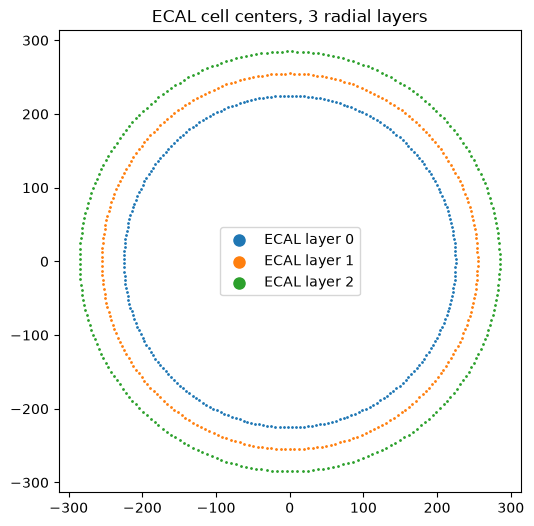

In [5]:
ecal = build_calo_stack(
    layer_id_base=100, r_inner=210.0, n_layers=3, thickness=30.0,
    n_phi=256, system="ecal", phi_stagger=[0.0, 0.5, 0.0],
)
ring = ecal[0]
idx = ring.cell_index(0.31)
print("phi=0.31 falls in cell", idx, "-> center phi", ring.cell_center_phi(idx), ", edges", ring.cell_edges(idx))

fig, ax = plt.subplots(figsize=(6, 6))
for i, r in enumerate(ecal):
    xs, ys = zip(*(r.cell_position(c) for c in range(r.n_phi)))
    ax.scatter(xs, ys, s=1, label=f"ECAL layer {i}")
ax.set_aspect("equal")
ax.legend(markerscale=8)
ax.set_title("ECAL cell centers, 3 radial layers")


## Muon stations

A muon spectrometer is a small number of large flat chambers arranged as a
polygon around the beamline, not a cylinder. Each *side* of the polygon is a
triplet of closely spaced planes, so a single crossing gives a local track
segment on its own. Size is set by the **apothem** (origin to the middle of
a side, not to a vertex), so a ray from the origin crosses each plane exactly
once.


72 LineLayers = 3 stations x 8 sides x 3 planes


Text(0.5, 1.0, 'Muon system: 3 octagonal stations, triplet planes per side')

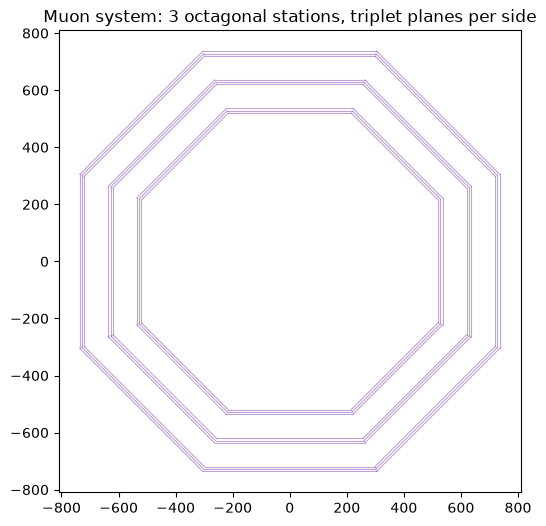

In [6]:
muon = build_muon_system(
    layer_id_base=300, apothem_inner=520.0, station_spacing=100.0,
    n_stations=3, n_planes=3, n_sides=8, triplet_gap=8.0,
)
print(f"{len(muon)} LineLayers = 3 stations x 8 sides x 3 planes")

fig, ax = plt.subplots(figsize=(6, 6))
for m in muon:
    ax.plot([m.p1[0], m.p2[0]], [m.p1[1], m.p2[1]], "-", color="tab:purple", alpha=0.6, lw=0.8)
ax.set_aspect("equal")
ax.set_title("Muon system: 3 octagonal stations, triplet planes per side")


## Piecewise fields and multi-segment trajectories

A real detector's field is strong inside the solenoid (tracker), ~zero in
the calorimeters, and reversed in the muon return yoke. `FieldRegions`
describes this as concentric shells of constant `bz`; `propagate` turns it
into a chain of arcs joined continuously in position *and* direction —
`SegmentedTrajectory` then presents the exact same `.position(s)`/
`.direction_at(s)` interface a plain `Trajectory` does.

`max_path_length` matters in practice: a low-`pt` particle that never leaves
its field region would otherwise circle forever.


3 arc segments, total path length 814.0


Text(0.5, 1.0, 'Trajectory through a piecewise (tracker / calo / muon) field')

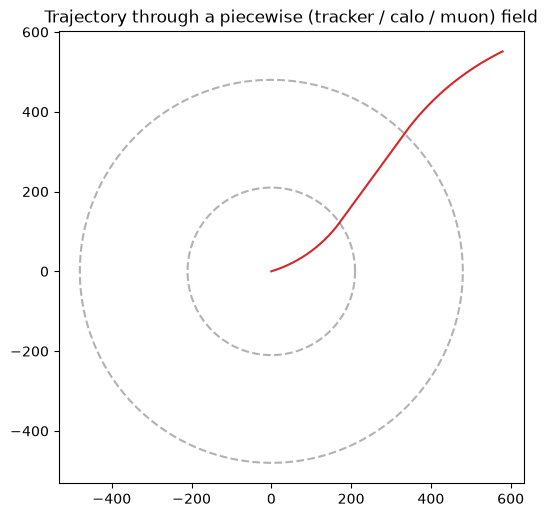

In [7]:
field = FieldRegions(regions=(
    FieldRegion(r_max=210.0, bz=+2.0),   # tracker: strong field
    FieldRegion(r_max=480.0, bz=0.0),    # calorimeters: none
    FieldRegion(r_max=None, bz=-1.0),    # muon system: reversed, half strength
), k=0.2998)

path = propagate(0.0, 0.0, phi0=0.3, charge=+1, pt=200.0, field=field,
                  world_radius=800.0, max_path_length=4000.0)
print(f"{len(path.segments)} arc segments, total path length {path.total_length:.1f}")

fig, ax = plt.subplots(figsize=(6, 6))
s_vals = np.linspace(0, path.total_length, 400)
xs, ys = zip(*(path.position(s) for s in s_vals))
ax.plot(xs, ys, color="tab:red")
for r in (210.0, 480.0):
    ax.plot(r * np.cos(theta), r * np.sin(theta), "k--", alpha=0.3)
ax.set_aspect("equal")
ax.set_title("Trajectory through a piecewise (tracker / calo / muon) field")


## Describing a detector layout from YAML

`detector2d.config` turns a plain dict — typically loaded from YAML by a
downstream package like `detectorsim2d` — into the flat layer list above,
via `build_layers_from_raw`. It understands the `layers:`/`detector:`
tracker block plus the optional `calorimeter:` and `muon:` blocks.


325 layers built from ../aihep/simulator/detectorsim2d/configs/barrel6.yaml


Text(0.5, 1.0, 'Detector layout built from barrel6.yaml')

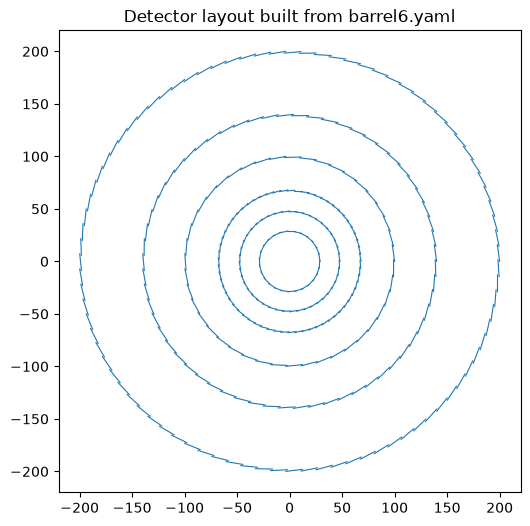

In [8]:
cfg_path = "../aihep/simulator/detectorsim2d/configs/barrel6.yaml"
with open(cfg_path) as f:
    raw = yaml.safe_load(f)

layers = build_layers_from_raw(raw)
print(f"{len(layers)} layers built from {cfg_path}")

fig, ax = plt.subplots(figsize=(6, 6))
for l in layers:
    if isinstance(l, LineLayer):
        ax.plot([l.p1[0], l.p2[0]], [l.p1[1], l.p2[1]], "-", color="tab:blue", lw=0.8)
    else:
        pts = np.linspace(0, 2 * np.pi, 100)
        ax.plot(l.center[0] + l.radius * np.cos(pts), l.center[1] + l.radius * np.sin(pts), "-", color="tab:blue", lw=0.8)
ax.set_aspect("equal")
ax.set_title("Detector layout built from barrel6.yaml")
